In [ ]:
!pip install pandas

In [ ]:
!pip install pm4py

In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

In [1]:
import pandas as pd
import pm4py
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import timedelta
import warnings
import numpy as np
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualization
from pm4py.util import constants
warnings.filterwarnings('ignore')

# Visualization configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
COLORS = {'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01', 
          'success': '#C73E1D', 'neutral': '#3B1F2B'}

## 1. Preprocessing

###1.1 Formatting columns for the compatibility with pm4py

In [3]:
from preprocessor import standardize_dataframe_for_pm4py

df = pd.read_csv("../event_log.csv")
complete_log = standardize_dataframe_for_pm4py(df)


### 1.2 Checking for missing data in case level attributes

In [4]:
case_attributes = [
    "case:concept:name",
    "case:arrival_transport",
    "case:disposition",
    "case:gender",
    "case:race",
    "case:acuity",
    "case:chiefcomplaint"
]


# Group by Case ID and take the first value found
grouped_by_case_log = complete_log[case_attributes].groupby("case:concept:name").first()

# 1. Basic Counts and Percentages
missing_count = grouped_by_case_log.isnull().sum()
missing_pct = (grouped_by_case_log.isnull().sum() / len(grouped_by_case_log)) * 100

# Combine into a clear report
missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_pct
}).sort_values(by='Percentage', ascending=False)

print(missing_report)

                        Missing Values  Percentage
case:acuity                         56    3.076923
case:arrival_transport               0    0.000000
case:disposition                     0    0.000000
case:gender                          0    0.000000
case:race                            0    0.000000
case:chiefcomplaint                  0    0.000000


### 1.3 Handling missing data in case level attributes
Case-level missing data analysis showed very low missingness across most attributes. Only acuity exhibited moderate missingness (3.08%), which was handled by introducing an explicit ‘Unknown’ category to avoid clinically unjustified imputation. Diagnosis-related attributes had negligible missingness (<0.2%) and were retained, with missing values flagged for downstream attribute-based analyses.

In [5]:
complete_log["case:acuity"] = complete_log["case:acuity"].fillna("N/A")

### 1.4 Case-Level Coverage of Activity Attributes

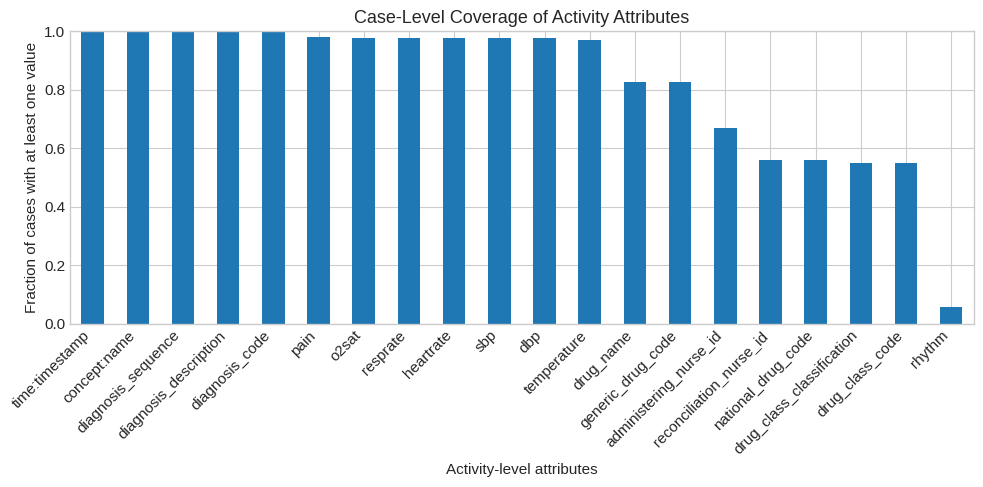

time:timestamp               1.000000
concept:name                 1.000000
diagnosis_sequence           0.998352
diagnosis_description        0.998352
diagnosis_code               0.998352
pain                         0.980769
o2sat                        0.978022
resprate                     0.978022
heartrate                    0.978022
sbp                          0.977473
dbp                          0.977473
temperature                  0.970879
drug_name                    0.828022
generic_drug_code            0.826374
administering_nurse_id       0.669231
reconciliation_nurse_id      0.560989
national_drug_code           0.560989
drug_class_classification    0.548901
drug_class_code              0.548901
rhythm                       0.057692
dtype: float64

In [6]:
activity_attributes = list(set(complete_log.columns) - set(case_attributes))
attr_coverage = (
    complete_log
    .groupby("case:concept:name")[activity_attributes]
    .apply(lambda x: x.notna().any())
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
attr_coverage.plot(kind="bar")
plt.ylabel("Fraction of cases with at least one value")
plt.xlabel("Activity-level attributes")
plt.title("Case-Level Coverage of Activity Attributes")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
attr_coverage

We analyzed missing activity-level attributes using a case-aware approach, measuring the fraction of cases in which each attribute was observed at least once. This analysis revealed that many attributes, such as vital signs and medication-related fields, are conditionally or event-specifically recorded, meaning their absence does not indicate data quality issues. Since process discovery and performance analysis rely solely on activity names and timestamps, no activity attributes were removed or imputed at this stage. Preserving missing values is essential to avoid introducing clinically unjustified assumptions and to enable correct pattern-based feature generation in later analysis stages.

### 1.5 Detect backward timestamps within cases (temporal anomalies).


### 1.6 Check for violations of expected clinical sequences in the ED process

In [6]:
from data_validation import validate_domain_order
validate_domain_order(complete_log)


STEP 4: DOMAIN-BASED ORDER VALIDATION

    Validating expected clinical sequences based on ED domain knowledge...

    Expected precedence rules:
    1. 'Enter the ED' → should be FIRST activity in every case
    2. 'Enter the ED' → 'Triage in the ED' (entry before triage)
    3. 'Triage in the ED' → 'Medicine administration' (triage before treatment)
    4. Any activity → 'Discharge from the ED' (discharge should be LAST)
    

✓ RESULTS:
  Start activities: {'Enter the ED': 1820}
  End activities: {'Discharge from the ED': 1820}

  ✓ No domain-based order violations detected!
    All cases follow the expected clinical sequence.

  Process boundary validation:
    ✓ All cases start with 'Enter the ED'
    ✓ All cases end with 'Discharge from the ED'


(Empty DataFrame
 Columns: []
 Index: [],
 {'Enter the ED': 1820},
 {'Discharge from the ED': 1820})


STEP 3: CONCURRENT/PARALLEL ACTIVITIES DETECTION

    Identifying events at exactly the same timestamp within cases...
    Concurrent activities indicate parallel execution or batch recording.
    

✓ RESULTS:
  - Cases with concurrent activities: 1,612 / 1,820 (88.6%)
  - Total concurrent activity groups: 4,362
  - Average activities per concurrent group: 3.00
  - Maximum concurrent activities: 43

  Top 10 most common concurrent activity pairs:
    Medicine reconciliation ‖ Medicine reconciliation: 16,692 times
    Medicine dispensations ‖ Medicine dispensations: 3,936 times
    Discharge from the ED ‖ Discharge from the ED: 2,948 times
    Enter the ED ‖ Vital sign check: 363 times
    Medicine reconciliation ‖ Vital sign check: 113 times
    Medicine dispensations ‖ Vital sign check: 34 times
    Medicine dispensations ‖ Medicine reconciliation: 30 times
    Enter the ED ‖ Medicine dispensations: 2 times

    INTERPRETATION:
    - High concurrency suggests batch recording or paral

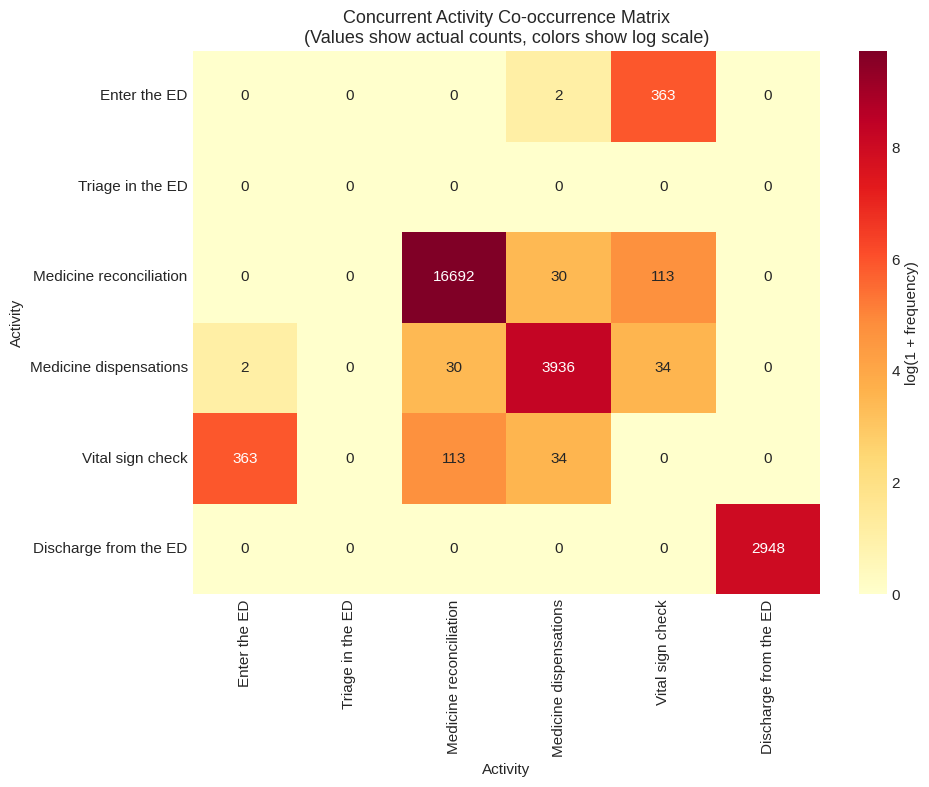

In [6]:
from data_validation import detect_concurrent_activities,create_concurrent_heatmap

concurrent_df, concurrent_cases, concurrent_pairs = detect_concurrent_activities(complete_log)
create_concurrent_heatmap(concurrent_pairs, complete_log)

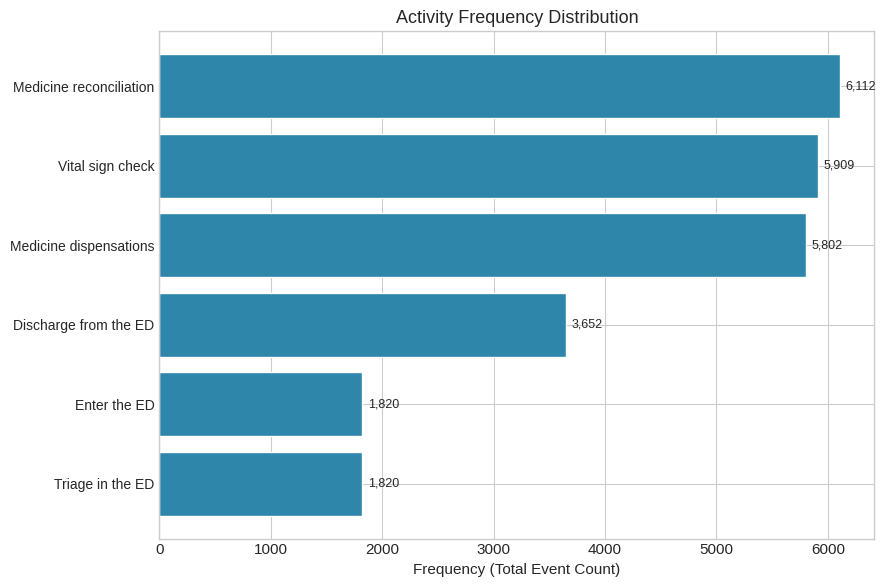

In [7]:
from data_validation import plot_activity_frequency
plot_activity_frequency(complete_log)

## 2. Performance analysis

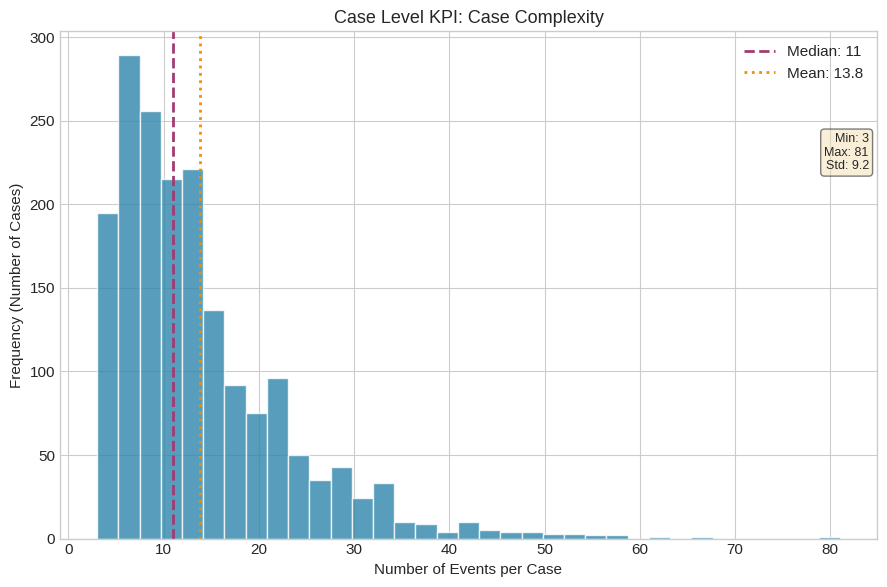

In [10]:
from kpi_calculation import plot_case_length_distribution
plot_case_length_distribution(complete_log)

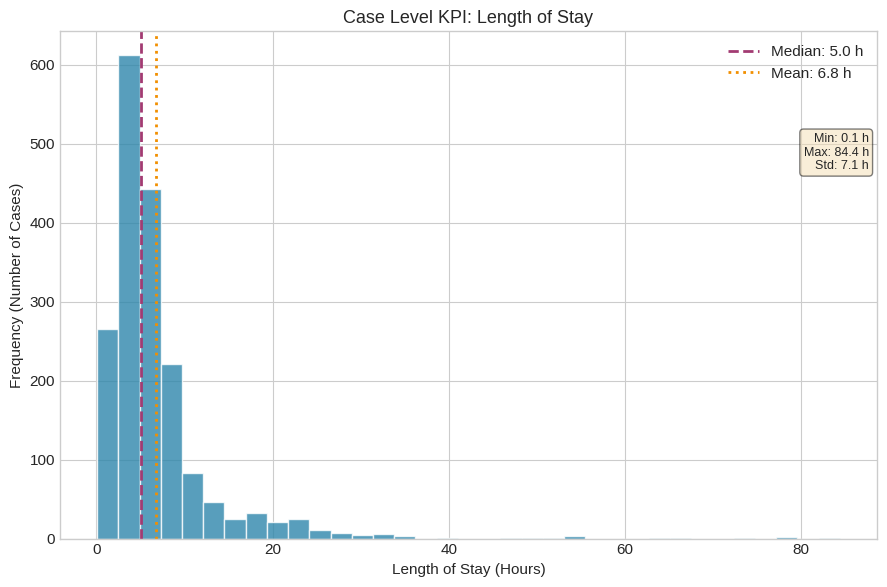

In [8]:
from kpi_calculation import plot_case_los_distribution
plot_case_los_distribution(complete_log)

In [ ]:
from kpi_calculation import plot_cumulative_lead_time
plot_cumulative_lead_time(complete_log)


VARIANT ANALYSIS

  Total cases: 1,820
  Total unique variants: 1307
  Variants per case: 0.718

  Pareto Analysis:
    Top 20% of variants (262) cover 42.6% of cases
    943 variants needed to cover 80% of cases (72.1% of variants)

  Top 10 most frequent variants:
  ----------------------------------------------------------------------
     1. Freq:   39 (  2.1%) | Len:  4 | Cum: 2.1%
     2. Freq:   28 (  1.5%) | Len:  3 | Cum: 3.7%
     3. Freq:   26 (  1.4%) | Len:  5 | Cum: 5.1%
     4. Freq:   24 (  1.3%) | Len:  6 | Cum: 6.4%
     5. Freq:   22 (  1.2%) | Len:  5 | Cum: 7.6%
     6. Freq:   15 (  0.8%) | Len:  6 | Cum: 8.5%
     7. Freq:   14 (  0.8%) | Len:  4 | Cum: 9.2%
     8. Freq:   13 (  0.7%) | Len:  4 | Cum: 9.9%
     9. Freq:   13 (  0.7%) | Len:  5 | Cum: 10.7%
    10. Freq:   12 (  0.7%) | Len:  6 | Cum: 11.3%

------------------------------------------------------------
  POWER-LAW DISTRIBUTION TEST
------------------------------------------------------------

  P

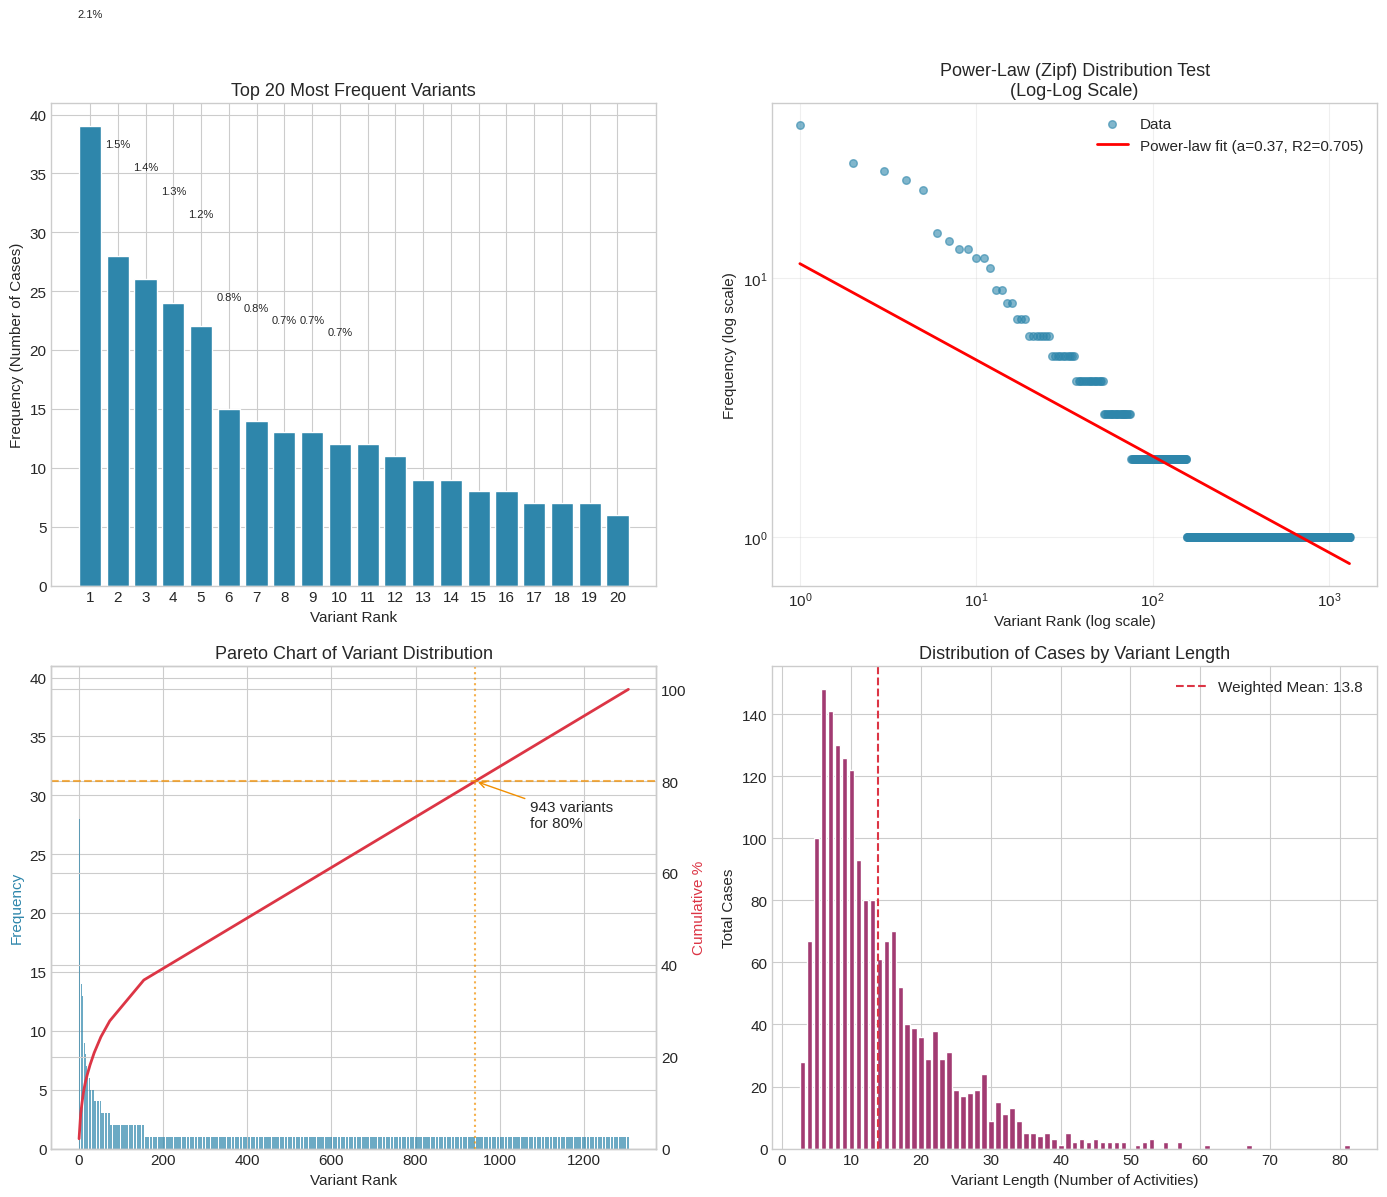

In [6]:
from variant_analysis import perform_sequential_variant_analysis

perform_sequential_variant_analysis(complete_log)